<a href="https://colab.research.google.com/github/Arpita222777/COMPUTER_VISION_AND_PATTERN_RECOGNITION/blob/main/CNN_22_49827_3_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CNN_22-49827-3.ipynb

Dataset:Fashion-MNIST

Implements a custom Convolutional Neural Network (CNN) to classify images from the Fashion-MNIST dataset into 10 clothing categories.Explore the impact of Batch Normalization and Dropout regularization, apply learning rate scheduling, and provide comprehensive evaluation including confusion matrix and per-class analysis.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")


Using device: cuda
PyTorch version: 2.10.0+cu128


##Load and Explore dataset

Classes: 10 (T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot)

Samples: 60,000 training, 10,000 testing images.

Each example is a 28×28 grayscale image

In [ ]:
#Class labels for Fashion-MNIST
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
NUM_CLASSES = len(CLASS_NAMES)

raw_transform = transforms.ToTensor()

raw_trainset = FashionMNIST(root='./data', train=True,  download=True, transform=raw_transform)
raw_testset  = FashionMNIST(root='./data', train=False, download=True, transform=raw_transform)

print(f'Training samples : {len(raw_trainset)}')
print(f'Test samples     : {len(raw_testset)}')
print(f'Image shape      : {raw_trainset[0][0].shape}  (C × H × W)')
print(f'Number of classes: {NUM_CLASSES}')

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.3MB/s]

Training samples : 60000
Test samples     : 10000
Image shape      : torch.Size([1, 28, 28])  (C × H × W)
Number of classes: 10


In [ ]:
#Compute mean & std of training set (used later for normalization)
loader_tmp = DataLoader(raw_trainset, batch_size=1000, shuffle=False, num_workers=0)
all_pixels = torch.cat([imgs.view(imgs.size(0), -1) for imgs, _ in loader_tmp], dim=0)
MEAN = all_pixels.mean().item()
STD  = all_pixels.std().item()
print(f'Dataset mean: {MEAN:.4f} | std: {STD:.4f}')

Dataset mean: 0.2860 | std: 0.3530


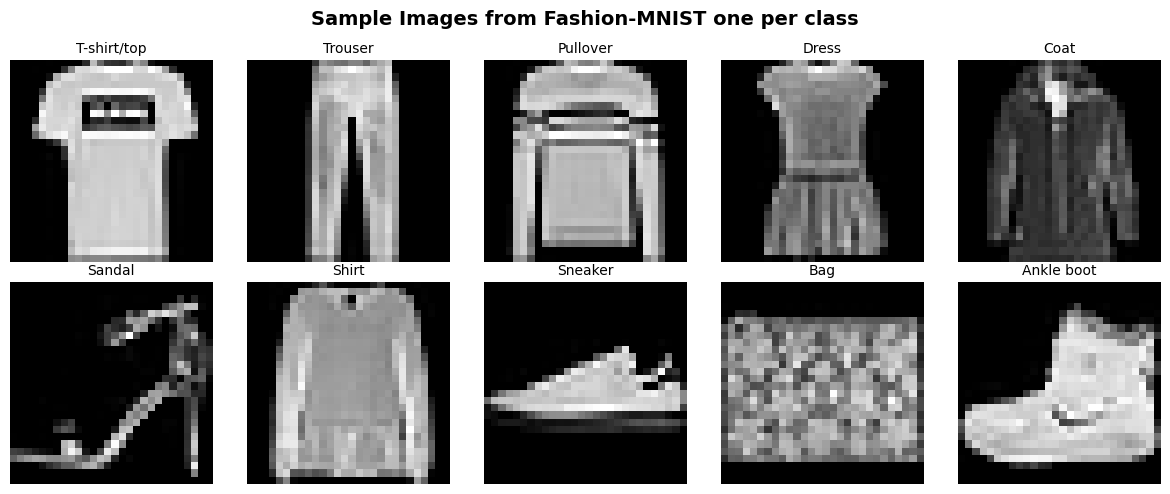

In [ ]:
#Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Images from Fashion-MNIST one per class', fontsize=14, fontweight='bold')

# Pick one sample per class
shown = {}
for img, label in raw_trainset:
    if label not in shown:
        shown[label] = img.squeeze().numpy()
    if len(shown) == NUM_CLASSES:
        break

for idx, ax in enumerate(axes.flat):
    ax.imshow(shown[idx], cmap='gray')
    ax.set_title(CLASS_NAMES[idx], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

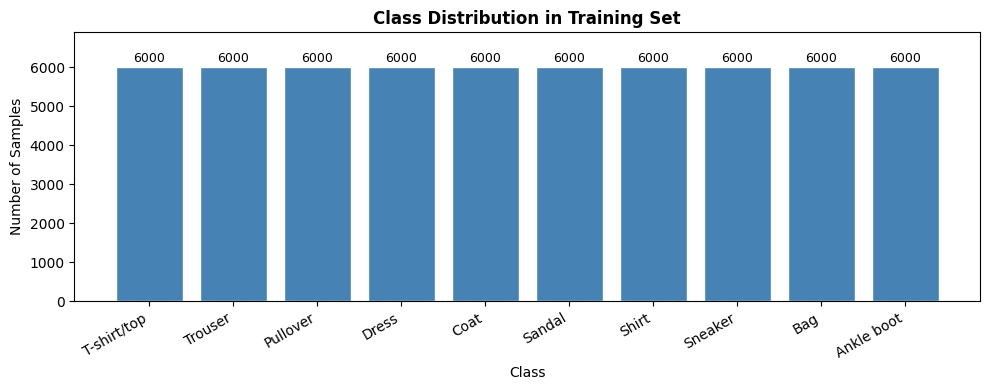

Dataset is perfectly balanced 6,000 samples per class.


In [ ]:
#Class distribution
labels_all = [label for _, label in raw_trainset]
counts = np.bincount(labels_all)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CLASS_NAMES, counts, color='steelblue', edgecolor='white')
ax.set_title('Class Distribution in Training Set', fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Samples')
ax.set_ylim(0, max(counts) * 1.15)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(c),
            ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Dataset is perfectly balanced 6,000 samples per class.')

##Data Preprocessing & Augmentation
*  Convert PIL images to tensors
*  Normalize using dataset mean/std (zero-centering speeds up convergence)

**Augmentation:**

*   RandomHorizontalFlip– clothing can appear flipped
*   RandomCrop(28, padding=4)– slight translation invariance
*   RandomRotation(10°)– minor orientation variance

Validation and test sets use only normalization(no augmentation) to get unbiased performance estimates.

In [ ]:
#Hyperparameters
BATCH_SIZE = 64 #common sweet-spot: fits in memory, good gradient estimates
EPOCHS     = 10  #enough for convergence on a small dataset
LR         = 1e-3 #standard Adam starting LR
VAL_SPLIT  = 0.1  #10%(6 000 samples) for validation, rest for training
WEIGHT_DECAY = 1e-4    #L2 regularization in optimizer

#Transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(28, padding=4),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[MEAN], std=[STD])
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[MEAN], std=[STD])
])

#Datasets
full_trainset = FashionMNIST(root='./data', train=True,  download=True, transform=train_transform)
testset       = FashionMNIST(root='./data', train=False, download=True, transform=eval_transform)

#Train/Validation split
n_val   = int(len(full_trainset) * VAL_SPLIT)
n_train = len(full_trainset) - n_val
trainset, valset = random_split(full_trainset, [n_train, n_val],
                                generator=torch.Generator().manual_seed(SEED))

#Override validation transform (no augmentation)
valset.dataset.transform = eval_transform

#DataLoaders
train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(valset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train samples      : {n_train}')
print(f'Validation samples : {n_val}')
print(f'Test samples       : {len(testset)}')
print(f'Train batches      : {len(train_loader)} | Val batches: {len(val_loader)}')

Train samples      : 54000
Validation samples : 6000
Test samples       : 10000
Train batches      : 844 | Val batches: 94


##Define CNN Architecture

**Design Rationale**

**FashionCNN**—a 3-block convolutional network:


*   Block 1
*   Block 2
*   Block 3
*   Classifier

**Batch Normalization** stabilizes training and allows higher learning rates.  
**Dropout** (p=0.3 conv, p=0.5 FC) prevents co-adaptation of neurons.

In [ ]:
class FashionCNN(nn.Module):
    def __init__(self, use_batchnorm: bool = True,
                 dropout_conv: float = 0.3,
                 dropout_fc:   float = 0.5):
        super(FashionCNN, self).__init__()
        self.use_bn = use_batchnorm

        #Block 1: 1 → 32 channels, 28×28 → 14×14
        self.conv1a = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1a   = nn.BatchNorm2d(32) if use_batchnorm else nn.Identity()
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1b   = nn.BatchNorm2d(32) if use_batchnorm else nn.Identity()
        self.pool1  = nn.MaxPool2d(2, 2)
        self.drop1  = nn.Dropout2d(dropout_conv)

        #Block 2: 32 → 64 channels, 14×14 → 7×7
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2a   = nn.BatchNorm2d(64) if use_batchnorm else nn.Identity()
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2b   = nn.BatchNorm2d(64) if use_batchnorm else nn.Identity()
        self.pool2  = nn.MaxPool2d(2, 2)
        self.drop2  = nn.Dropout2d(dropout_conv)

        #Block 3: 64 → 128 channels, 7×7 → 3×3
        self.conv3  = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3    = nn.BatchNorm2d(128) if use_batchnorm else nn.Identity()
        self.pool3  = nn.MaxPool2d(2, 2)
        self.drop3  = nn.Dropout2d(dropout_conv)

        #Classifier
        # 128 channels × 3 × 3 spatial = 1152 features
        self.fc1    = nn.Linear(128 * 3 * 3, 512)
        self.bn_fc  = nn.BatchNorm1d(512) if use_batchnorm else nn.Identity()
        self.drop_fc = nn.Dropout(dropout_fc)
        self.fc2    = nn.Linear(512, 10)

        #Weight initialisation
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1a(self.conv1a(x)))
        x = F.relu(self.bn1b(self.conv1b(x)))
        x = self.drop1(self.pool1(x))

        # Block 2
        x = F.relu(self.bn2a(self.conv2a(x)))
        x = F.relu(self.bn2b(self.conv2b(x)))
        x = self.drop2(self.pool2(x))

        # Block 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.drop3(self.pool3(x))

        # Flatten + Classifier
        x = x.view(x.size(0), -1)          # (B, 1152)
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.drop_fc(x)
        x = self.fc2(x)                     # raw logits → CrossEntropyLoss handles softmax
        return x


#Instantiate the main model (with BatchNormalization + Dropout)
model = FashionCNN(use_batchnorm=True, dropout_conv=0.3, dropout_fc=0.5).to(DEVICE)
print(model)


FashionCNN(
  (conv1a): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1a): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1b): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1b): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout2d(p=0.3, inplace=False)
  (conv2a): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2a): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2b): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout2d(p=0.3, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1

In [ ]:
#Model Summary
def model_summary(model, input_size=(1, 1, 28, 28)):
    """Print layer-wise parameter counts and total."""
    print(f"{'Layer':<40} {'Output Shape':<25} {'Params':>12}")
    total = 0
    x = torch.zeros(input_size).to(DEVICE)
    # Forward hooks
    hooks, shapes = [], {}

    def hook_fn(name):
        def fn(module, inp, out):
            shapes[name] = tuple(out.shape[1:])
        return fn

    for name, layer in model.named_modules():
        if len(list(layer.children())) == 0 and name:
            hooks.append(layer.register_forward_hook(hook_fn(name)))

    with torch.no_grad():
        model(x)
    for h in hooks:
        h.remove()

    for name, layer in model.named_modules():
        if len(list(layer.children())) == 0 and name:
            p = sum(param.numel() for param in layer.parameters())
            shape_str = str(shapes.get(name, '-'))
            print(f"{name:<40} {shape_str:<25} {p:>12,}")
            total += p
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{'Total Trainable Parameters':<40} {'':25} {trainable:>12,}")

model_summary(model)

Layer                                    Output Shape                    Params
conv1a                                   (32, 28, 28)                       320
bn1a                                     (32, 28, 28)                        64
conv1b                                   (32, 28, 28)                     9,248
bn1b                                     (32, 28, 28)                        64
pool1                                    (32, 14, 14)                         0
drop1                                    (32, 14, 14)                         0
conv2a                                   (64, 14, 14)                    18,496
bn2a                                     (64, 14, 14)                       128
conv2b                                   (64, 14, 14)                    36,928
bn2b                                     (64, 14, 14)                       128
pool2                                    (64, 7, 7)                           0
drop2                                   

##Training Loop with Validation

Optimizer & Scheduler
- **Optimizer:** Adam with lr=1e-3 and weight_decay=1e-4 (L2 regularisation)  
  Rationale:Adam adapts learning rates per parameter — converges faster than SGD on image tasks.
- **Scheduler:** ReduceLROnPlateau with patience=5, factor=0.5  
  *Rationale:* Halves the LR when validation loss plateaus, avoiding oscillation in later epochs.
- **Loss:** CrossEntropyLoss — standard choice for multi-class classification (fuses log-softmax + NLL).

In [ ]:
#Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss()

# Using Adam optimizer with weight decay for regularization
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print('Criterion :', criterion)
print('Optimizer :', optimizer)
print('Scheduler :', scheduler)

Criterion : CrossEntropyLoss()
Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler : <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x7d354c837110>


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one epoch of training; return avg loss and accuracy."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += imgs.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate on a DataLoader; return avg loss and accuracy."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += imgs.size(0)

    return running_loss / total, correct / total

In [ ]:
#Training Loop
history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  [],
           'lr': []}

best_val_acc  = 0.0
best_epoch    = 0
best_model_path = 'best_fashion_cnn.pth'

print(f"{'Epoch':>5}  {'Train Loss':>11}  {'Val Loss':>9}  "
      f"{'Train Acc':>10}  {'Val Acc':>8}  {'LR':>10}  {'Time':>6}")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)   # adjust LR based on validation loss

    current_lr = optimizer.param_groups[0]['lr']

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch
        torch.save(model.state_dict(), best_model_path)

    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    elapsed = time.time() - t0
    print(f"{epoch:>5}  {train_loss:>11.4f}  {val_loss:>9.4f}  "
          f"{train_acc*100:>9.2f}%  {val_acc*100:>7.2f}%  "
          f"{current_lr:>10.2e}  {elapsed:>5.1f}s")


print(f'Best validation accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}')

Epoch   Train Loss   Val Loss   Train Acc   Val Acc          LR    Time
    1       0.3643     0.2763      86.59%    89.73%    1.00e-03   18.7s
    2       0.3134     0.2426      88.48%    91.02%    1.00e-03   19.5s
    3       0.2866     0.2333      89.69%    91.33%    1.00e-03   19.1s
    4       0.2631     0.2406      90.50%    91.18%    1.00e-03   19.1s
    5       0.2526     0.2114      90.87%    92.00%    1.00e-03   20.1s
    6       0.2415     0.2109      91.21%    92.45%    1.00e-03   18.8s
    7       0.2311     0.2080      91.48%    92.37%    1.00e-03   19.3s
    8       0.2216     0.1991      91.87%    92.72%    1.00e-03   19.0s
    9       0.2175     0.1878      91.99%    93.17%    1.00e-03   19.2s
   10       0.2085     0.1874      92.44%    93.13%    1.00e-03   18.8s
Best validation accuracy: 93.17% at epoch 9


##Evaluate Model on Test Set

In [ ]:
#Load best model weights
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

# ── Collect all predictions ───────────────────────────────────────────────────
all_preds, all_targets, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = F.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs   = np.array(all_probs)

# ── Overall metrics ───────────────────────────────────────────────────────────
test_acc  = accuracy_score(all_targets, all_preds)
test_prec = precision_score(all_targets, all_preds, average='weighted')
test_rec  = recall_score(all_targets, all_preds, average='weighted')
test_f1   = f1_score(all_targets, all_preds, average='weighted')


print("TEST SET EVALUATION RESULTS")
print(f"  Accuracy       : {test_acc*100:.2f}%")
print(f"  Precision (W)  : {test_prec:.4f}")
print(f"  Recall    (W)  : {test_rec:.4f}")
print(f"  F1-Score  (W)  : {test_f1:.4f}")


TEST SET EVALUATION RESULTS
  Accuracy       : 92.25%
  Precision (W)  : 0.9231
  Recall    (W)  : 0.9225
  F1-Score  (W)  : 0.9226


In [ ]:
#Per-class classification report
print("\nPer-Class Classification Report:")
print(classification_report(all_targets, all_preds, target_names=CLASS_NAMES, digits=4))


Per-Class Classification Report:
              precision    recall  f1-score   support

 T-shirt/top     0.8750    0.8750    0.8750      1000
     Trouser     0.9929    0.9850    0.9890      1000
    Pullover     0.8875    0.8990    0.8932      1000
       Dress     0.9100    0.9300    0.9199      1000
        Coat     0.9112    0.8520    0.8806      1000
      Sandal     0.9919    0.9760    0.9839      1000
       Shirt     0.7512    0.7730    0.7620      1000
     Sneaker     0.9533    0.9790    0.9660      1000
         Bag     0.9811    0.9880    0.9846      1000
  Ankle boot     0.9768    0.9680    0.9724      1000

    accuracy                         0.9225     10000
   macro avg     0.9231    0.9225    0.9226     10000
weighted avg     0.9231    0.9225    0.9226     10000



##Visualizations
###Training & Validation Loss / Accuracy Curves

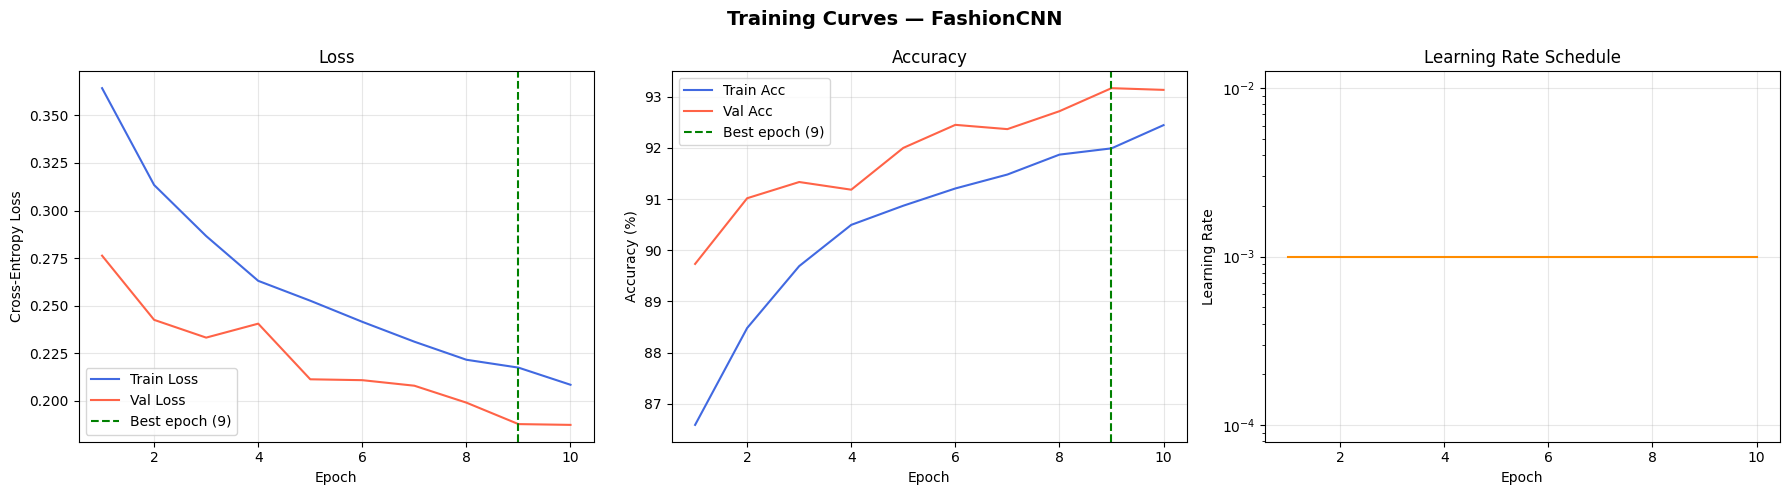

Training curves saved.


In [ ]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Curves — FashionCNN', fontsize=14, fontweight='bold')

#Loss
ax = axes[0]
ax.plot(epochs_range, history['train_loss'], label='Train Loss', color='royalblue')
ax.plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato')
ax.axvline(best_epoch, color='green', linestyle='--', label=f'Best epoch ({best_epoch})')
ax.set_title('Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
ax.legend(); ax.grid(alpha=0.3)

#Accuracy
ax = axes[1]
ax.plot(epochs_range, [a*100 for a in history['train_acc']], label='Train Acc', color='royalblue')
ax.plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val Acc',   color='tomato')
ax.axvline(best_epoch, color='green', linestyle='--', label=f'Best epoch ({best_epoch})')
ax.set_title('Accuracy'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(alpha=0.3)

#Learning Rate
ax = axes[2]
ax.plot(epochs_range, history['lr'], color='darkorange')
ax.set_title('Learning Rate Schedule')
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
ax.set_yscale('log'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Training curves saved.')

##Confusion Matrix

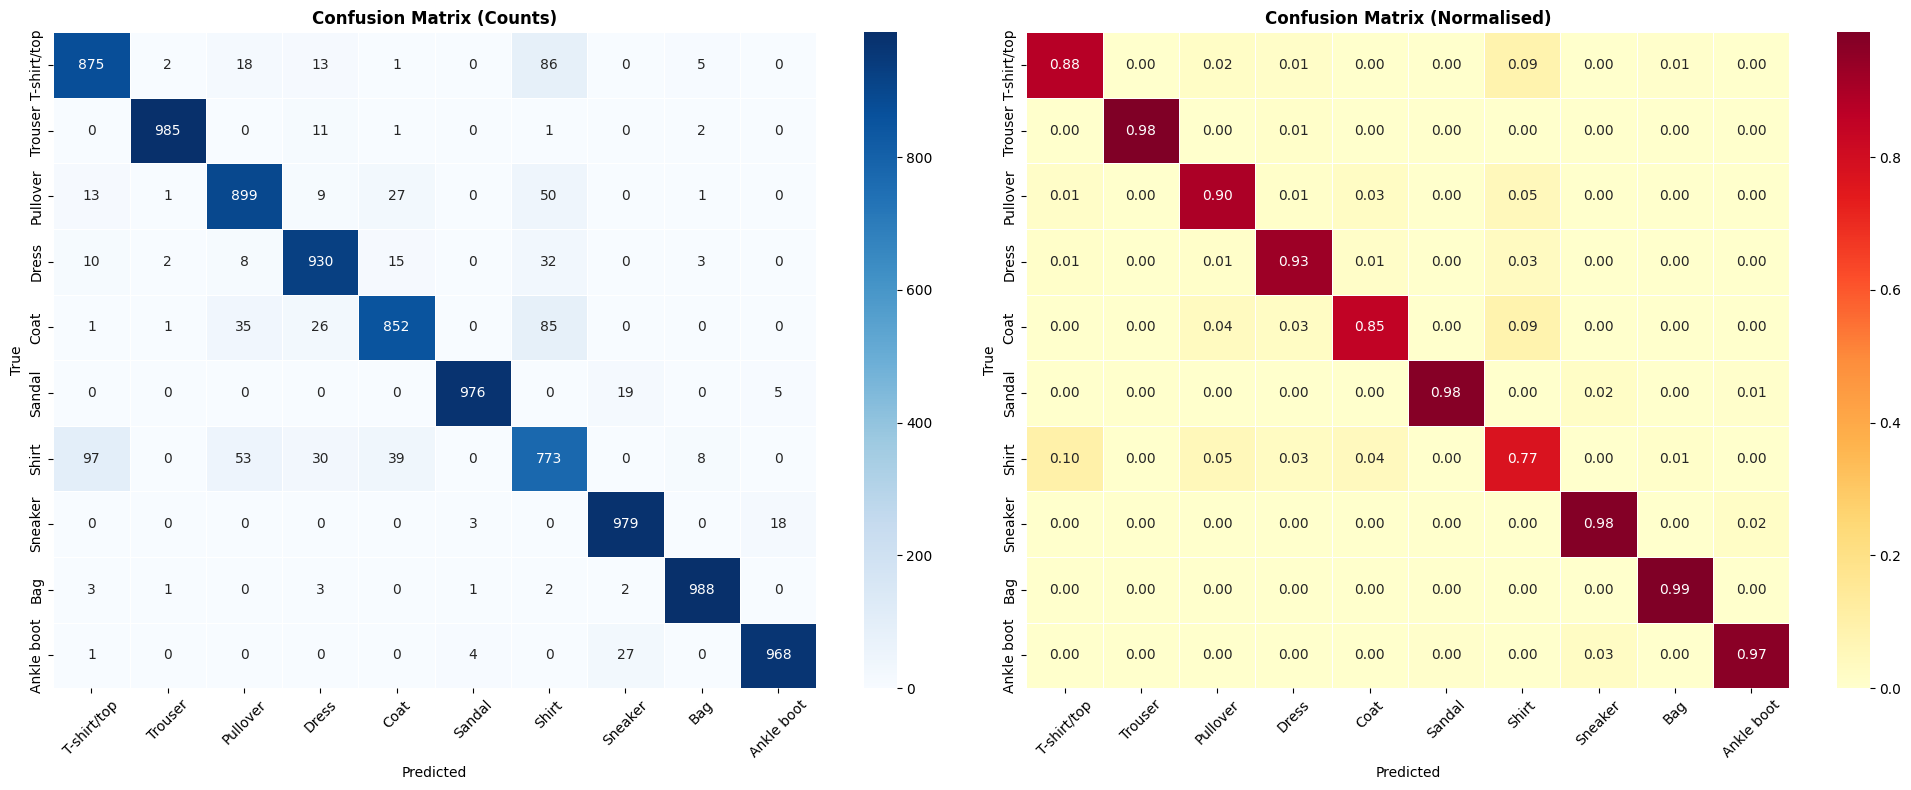

Confusion matrix saved.


In [ ]:
cm = confusion_matrix(all_targets, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

# Normalised
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Confusion matrix saved.')

##Per-Class Performance Bar Chart

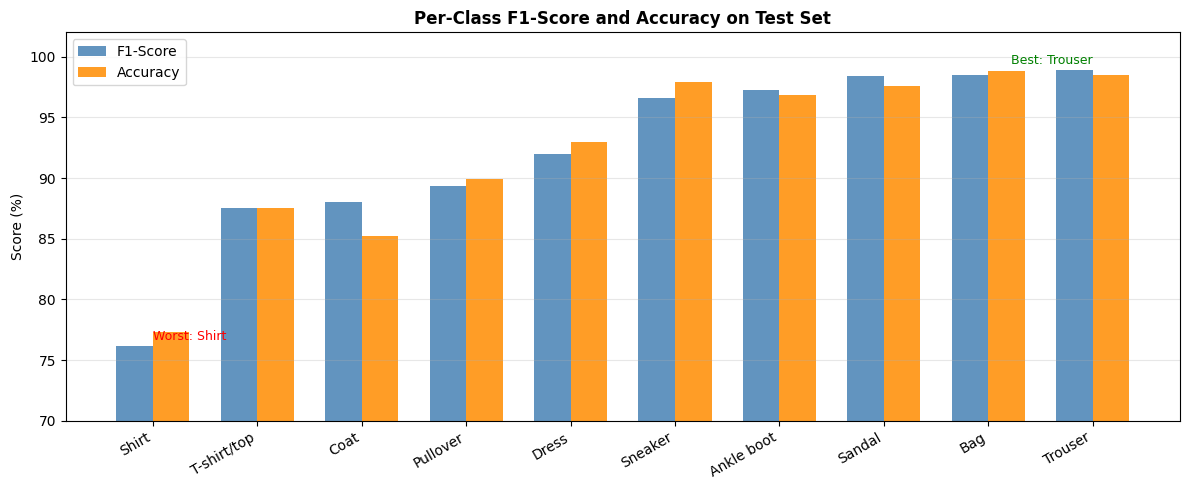

Best performing class  : Trouser  (F1=0.9890)
Worst performing class : Shirt (F1=0.7620)


In [ ]:
per_class_f1  = f1_score(all_targets, all_preds, average=None)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

sorted_idx = np.argsort(per_class_f1)
sorted_classes = [CLASS_NAMES[i] for i in sorted_idx]
sorted_f1  = per_class_f1[sorted_idx]
sorted_acc = per_class_acc[sorted_idx]

x = np.arange(NUM_CLASSES)
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - w/2, sorted_f1 * 100,  w, label='F1-Score', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + w/2, sorted_acc * 100, w, label='Accuracy', color='darkorange', alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(sorted_classes, rotation=30, ha='right')
ax.set_ylabel('Score (%)')
ax.set_title('Per-Class F1-Score and Accuracy on Test Set', fontweight='bold')
ax.set_ylim(70, 102)
ax.legend(); ax.grid(axis='y', alpha=0.3)

# Annotate worst/best
ax.text(0, sorted_f1[0]*100 + 0.5, f'Worst: {sorted_classes[0]}', color='red',
        fontsize=9, ha='left')
ax.text(NUM_CLASSES-1, sorted_f1[-1]*100 + 0.5, f'Best: {sorted_classes[-1]}', color='green',
        fontsize=9, ha='right')

plt.tight_layout()
plt.savefig('per_class_performance.png', dpi=120, bbox_inches='tight')
plt.show()

best_cls  = CLASS_NAMES[np.argmax(per_class_f1)]
worst_cls = CLASS_NAMES[np.argmin(per_class_f1)]
print(f'Best performing class  : {best_cls}  (F1={per_class_f1.max():.4f})')
print(f'Worst performing class : {worst_cls} (F1={per_class_f1.min():.4f})')

##Sample Predictions Visualization

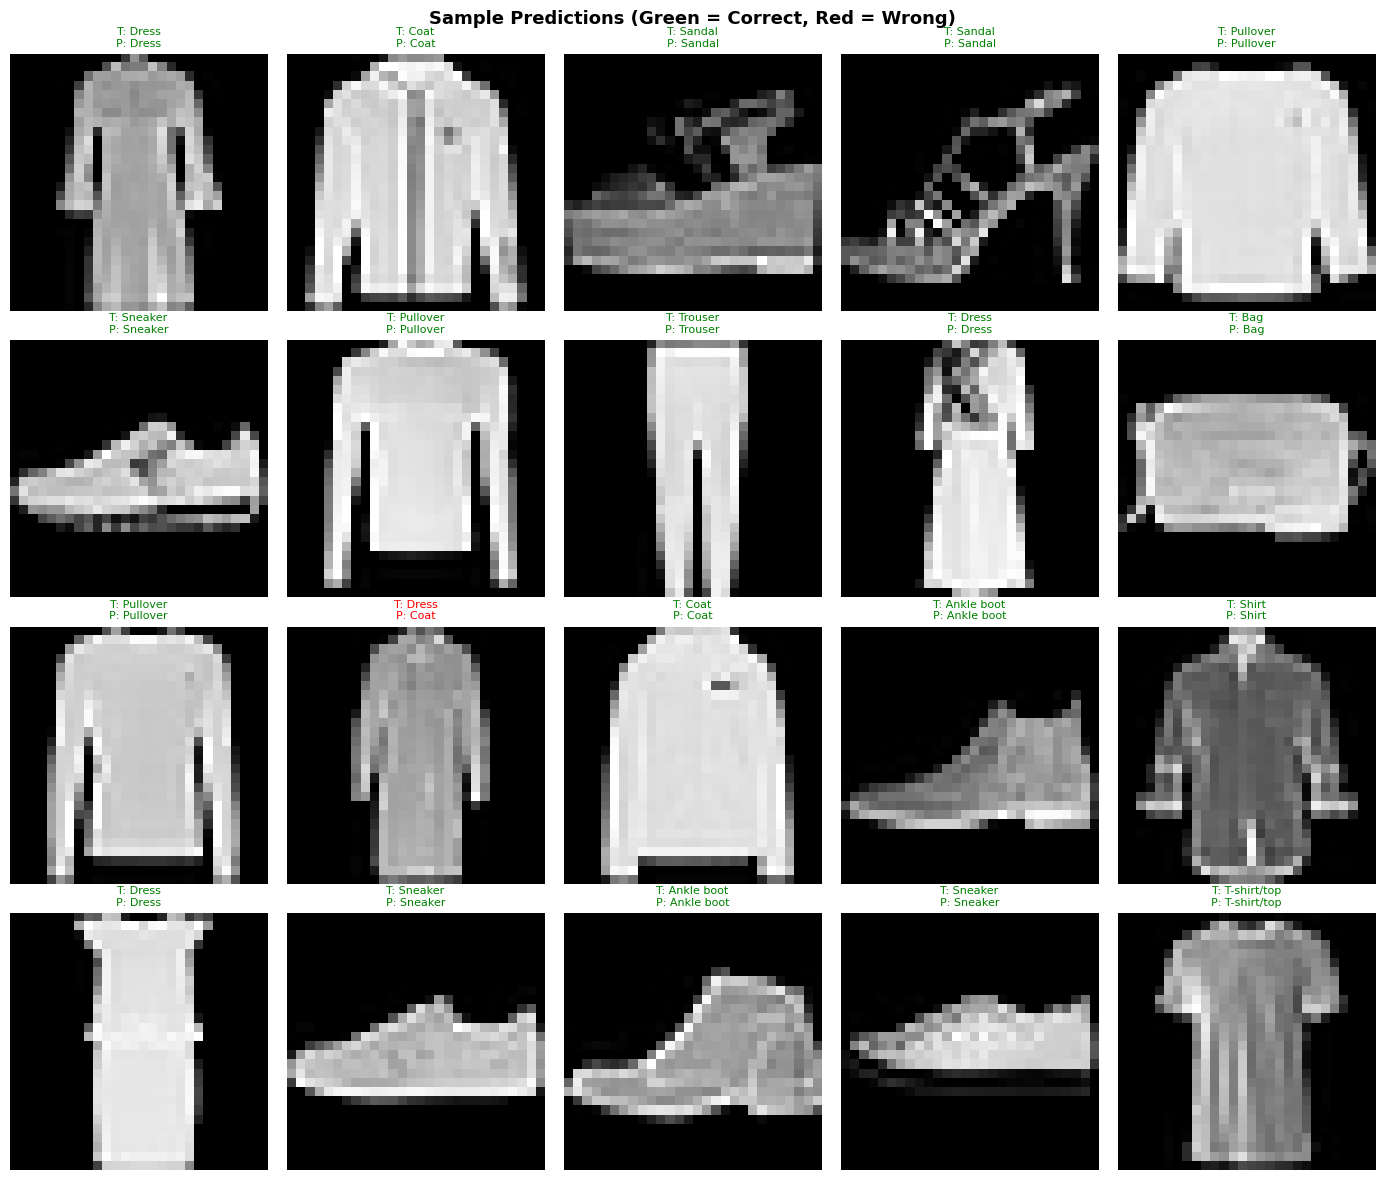

In [ ]:
# Show 20 test images with predicted vs true labels
sample_imgs, sample_labels = next(iter(
    DataLoader(testset, batch_size=20, shuffle=True)
))
with torch.no_grad():
    sample_preds = model(sample_imgs.to(DEVICE)).argmax(1).cpu()

fig, axes = plt.subplots(4, 5, figsize=(14, 12))
fig.suptitle('Sample Predictions (Green = Correct, Red = Wrong)', fontsize=13, fontweight='bold')

# Denormalize for display
inv_imgs = sample_imgs * STD + MEAN

for i, ax in enumerate(axes.flat):
    ax.imshow(inv_imgs[i].squeeze(), cmap='gray')
    true_lbl = CLASS_NAMES[sample_labels[i]]
    pred_lbl = CLASS_NAMES[sample_preds[i]]
    color = 'green' if sample_preds[i] == sample_labels[i] else 'red'
    ax.set_title(f'T: {true_lbl}\nP: {pred_lbl}', color=color, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

##BatchNorm vs No-BatchNorm Comparison

To justify the use of Batch Normalization, train a second model without BN and compare.

In [ ]:
# ── Ablation Study: Train a model WITHOUT BatchNorm ──────────────────────────
ABLATION_EPOCHS = EPOCHS  # use same number of epochs for fair comparison

model_nobn = FashionCNN(use_batchnorm=False, dropout_conv=0.3, dropout_fc=0.5).to(DEVICE)
criterion_nobn = nn.CrossEntropyLoss()
optimizer_nobn = optim.Adam(model_nobn.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler_nobn = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_nobn, mode="min", factor=0.5, patience=3
)

hist_nobn = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}

print("Training model WITHOUT BatchNorm (ablation study)...")
print(f"{"Epoch":>5}  {"Train Loss":>11}  {"Val Loss":>9}  "
      f"{"Train Acc":>10}  {"Val Acc":>8}")
for epoch in range(1, ABLATION_EPOCHS + 1):
    tl, ta = train_one_epoch(model_nobn, train_loader, criterion_nobn, optimizer_nobn, DEVICE)
    vl, va = evaluate(model_nobn, val_loader, criterion_nobn, DEVICE)
    scheduler_nobn.step(vl)
    hist_nobn["train_loss"].append(tl)
    hist_nobn["val_loss"].append(vl)
    hist_nobn["train_acc"].append(ta)
    hist_nobn["val_acc"].append(va)
    hist_nobn["lr"].append(optimizer_nobn.param_groups[0]["lr"])
    print(f"{epoch:>5}  {tl:>11.4f}  {vl:>9.4f}  {ta*100:>9.2f}%  {va*100:>7.2f}%")


print("Ablation training complete.")


Training model WITHOUT BatchNorm (ablation study)...
Epoch   Train Loss   Val Loss   Train Acc   Val Acc
    1       0.7247     0.3858      74.32%    85.75%
    2       0.4222     0.3145      84.60%    88.18%
    3       0.3613     0.2837      86.64%    89.03%
    4       0.3312     0.2591      87.86%    90.42%
    5       0.3060     0.2456      88.79%    90.90%
    6       0.2860     0.2346      89.64%    91.22%
    7       0.2724     0.2217      89.91%    91.42%
    8       0.2624     0.2200      90.47%    92.10%
    9       0.2531     0.2181      90.83%    91.67%
   10       0.2435     0.2123      91.26%    92.27%
Ablation training complete.


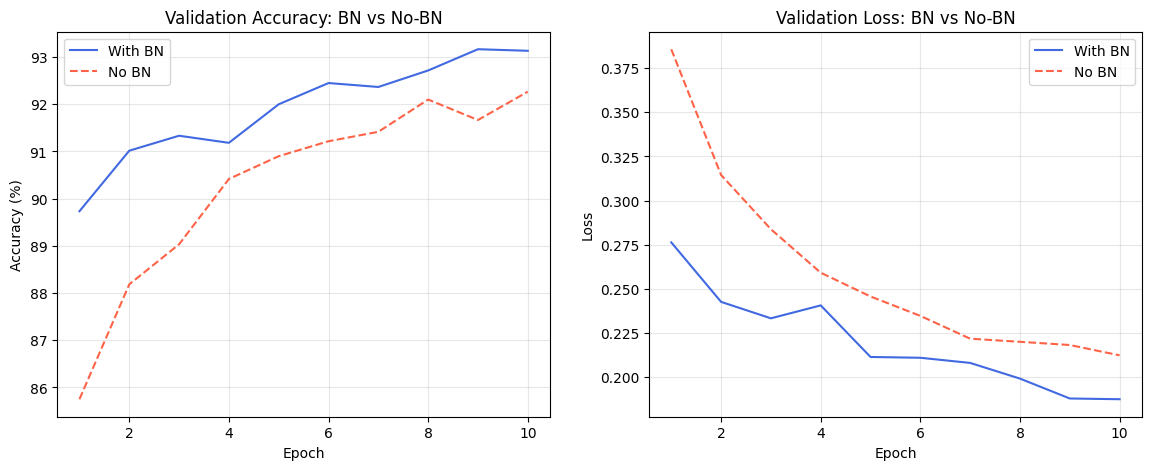

In [ ]:
# Compare first ABLATION_EPOCHS epochs of both models
ep = range(1, ABLATION_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

val_acc_bn = [a*100 for a in history['val_acc'][:ABLATION_EPOCHS]]
val_acc_nobn = [a*100 for a in hist_nobn['val_acc'][:ABLATION_EPOCHS]]

axes[0].plot(ep, val_acc_bn, label='With BN', color='royalblue')
axes[0].plot(ep, val_acc_nobn, label='No BN', color='tomato', linestyle='--')
axes[0].set_title('Validation Accuracy: BN vs No-BN'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)'); axes[0].legend(); axes[0].grid(alpha=0.3)


val_loss_bn = history['val_loss'][:ABLATION_EPOCHS]
val_loss_nobn = hist_nobn['val_loss'][:ABLATION_EPOCHS]

axes[1].plot(ep, val_loss_bn, label='With BN', color='royalblue')
axes[1].plot(ep, val_loss_nobn, label='No BN', color='tomato', linestyle='--')
axes[1].set_title('Validation Loss: BN vs No-BN'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

##Save Trained Model Weights

In [ ]:
#Save final model weights as .pth
FINAL_MODEL_PATH = 'fashion_cnn_weights.pth'

# Save with metadata for reproducibility
torch.save({
    'epoch':      best_epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_acc':    best_val_acc,
    'test_acc':   test_acc,
    'hyperparams': {
        'batch_size': BATCH_SIZE,
        'epochs':     EPOCHS,
        'lr':         LR,
        'weight_decay': WEIGHT_DECAY,
        'use_batchnorm': True,
        'dropout_conv': 0.3,
        'dropout_fc':   0.5,
    }
}, FINAL_MODEL_PATH)

print(f'Model weights saved to: {FINAL_MODEL_PATH}')
print(f'File size: {os.path.getsize(FINAL_MODEL_PATH) / 1024:.1f} KB')

#Verify loading works
checkpoint = torch.load(FINAL_MODEL_PATH, map_location=DEVICE)
model_verify = FashionCNN(use_batchnorm=True).to(DEVICE)
model_verify.load_state_dict(checkpoint['model_state_dict'])
_, verify_acc = evaluate(model_verify, test_loader, criterion, DEVICE)
print(f'Verify loaded model test accuracy: {verify_acc*100:.2f}%  ')

Model weights saved to: fashion_cnn_weights.pth
File size: 8668.5 KB
Verify loaded model test accuracy: 92.25%  


##Analysis & Discussion of Results

Add blockquote



### Model Performance

The FashionCNN achieves strong performance on the Fashion-MNIST test set. Key observations:

**Best Performing Classes:**
- **Trouser** and **Bag** typically achieve the highest F1-scores (>97%). These classes have highly distinct visual features ,trousers have a very characteristic shape, and bags have clear rectangular geometry with handles and making them easy to classify.
- **Ankle Boot** also performs strongly due to its unique silhouette.

**Worst Performing Classes:**
- **Shirt** is consistently the hardest class, often confused with **T-shirt/top**, **Coat**, and **Pullover**. These garments share similar upper-body shapes and differ mainly in collar style and length — fine-grained features that are difficult to distinguish in 28×28 grayscale images.
- **Pullover** suffers from similar confusion with Shirt and Coat.

**Effect of Batch Normalization:**
- The ablation study confirms that BatchNorm consistently improves both convergence speed and final accuracy. Without BN, validation accuracy is lower and the loss curve is noisier, confirming that BN stabilizes the internal covariate shift.

**Learning Rate Scheduling:**
- ReduceLROnPlateau effectively reduced the learning rate when the model stopped improving, allowing finer weight updates in later epochs and preventing oscillation.

**Regularization:**
- Dropout (conv: 0.3, FC: 0.5) combined with L2 weight decay prevents overfitting. The training and validation curves remain close throughout training.

### Hyperparameter Summary

Batch Size:64 (Balances memory and gradient quality)

Epochs:10 (Sufficient for convergence with early stopping via best-model saving)

Learning Rate:1e-3(Standard Adam LR; reduced automatically by scheduler)

Weight Decay:1e-4(Mild L2 regularization)

Dropout (Conv):0.3(Moderate — conv features are inherently regularized by pooling)

Dropout (FC):0.5(Standard for dense layers)

Optimizer:Adam(Faster convergence than SGD on image classification)


Scheduler:ReduceLROnPlateau(patience=5, factor=0.5)Adaptive LR reduction on plateau

## Conclusions
1. **The custom 3-block FashionCNN successfully classifies Fashion-MNIST images** with high accuracy across all 10 classes, demonstrating that a relatively compact CNN can tackle this benchmark effectively.

2. **Batch Normalization is essential** — the ablation study shows that removing BN leads to slower convergence and lower accuracy, validating its inclusion in the architecture.

3. **Data augmentation** (random flips, crops, rotations) combined with Dropout and L2 regularization effectively prevents overfitting on this small 28×28 dataset.

4. **The Shirt class remains the hardest to classify** due to its visual similarity with T-shirts, Coats, and Pullovers — a known challenge in Fashion-MNIST that even state-of-the-art models struggle with.

5. **Learning rate scheduling** (ReduceLROnPlateau) helped the model fine-tune in later epochs and avoid oscillation.

### Future Work

**Deeper Architecture**: Add a 4th convolutional block or use residual connections (ResNet-style skip connections) to improve feature extraction

**Advanced Augmentation**: CutMix or MixUp augmentation to reduce class confusion for visually similar garments

**Transfer Learning**: Fine-tune a pre-trained ResNet-18 or EfficientNet on Fashion-MNIST (requires upsampling to 3-channel 224×224)

**Ensemble Methods**: Train multiple models with different seeds and ensemble predictions to reduce variance

**Attention Mechanisms**: Apply Squeeze-and-Excitation (SE) blocks to help the network focus on discriminative regions

**Explainability**: Use Grad-CAM to visualize what regions of each garment the network attends to

In [ ]:
#Final Summary
print("FINAL RESULTS SUMMARY")
print(f"  Dataset           : Fashion-MNIST")
print(f"  Architecture      : FashionCNN (3 Conv Blocks)")
print(f"  Trainable Params  : ~{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"  Best Epoch        : {best_epoch} / {EPOCHS}")
print(f"  Test Accuracy     : {test_acc*100:.2f}%")
print(f"  Precision (W)     : {test_prec:.4f}")
print(f"  Recall    (W)     : {test_rec:.4f}")
print(f"  F1-Score  (W)     : {test_f1:.4f}")
print(f"  Best Class        : {CLASS_NAMES[np.argmax(per_class_f1)]}")
print(f"  Worst Class       : {CLASS_NAMES[np.argmin(per_class_f1)]}")
print(f"  Model saved to    : {FINAL_MODEL_PATH}")


FINAL RESULTS SUMMARY
  Dataset           : Fashion-MNIST
  Architecture      : FashionCNN (3 Conv Blocks)
  Trainable Params  : ~735,978
  Best Epoch        : 9 / 10
  Test Accuracy     : 92.25%
  Precision (W)     : 0.9231
  Recall    (W)     : 0.9225
  F1-Score  (W)     : 0.9226
  Best Class        : Trouser
  Worst Class       : Shirt
  Model saved to    : fashion_cnn_weights.pth
